<a href="https://colab.research.google.com/github/ivanduzunov/AI-Agents-and-Workflows-for-Developers/blob/main/AI_AGENTS_LangChain_Agents_%26_Tools.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [86]:
!pip install -q langchain langchain-openai langchain-community langchain-chroma langchain-text-splitters

In [ ]:
# Agent
# Model
# Tools
# Loader -> load documents
# Splitter ->
# Retriever
# Middleware
# Chekpoinnter
# Store
# Vector Store
# Graph + Node


In [168]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain.messages import AIMessage, HumanMessage, SystemMessage
from langchain_core.messages import BaseMessage
from langchain_core.tools import create_retriever_tool
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain_chroma import Chroma
from langchain.tools import tool
from langchain.agents.middleware.types import after_model
from langchain.agents import AgentState
from langgraph.runtime import Runtime
from google.colab import userdata
from pydantic import SecretStr
from typing import List
from IPython.display import Image
import json

In [37]:

def print_conversation(messages: List[BaseMessage]):
  for message in messages:
    message.pretty_print()

In [53]:
api_key = SecretStr(userdata.get('OPENAI_KEY'))
model = ChatOpenAI(model_name="gpt-5-nano", api_key=api_key, use_responses_api=True)

In [11]:
text_loader = TextLoader("/content/company_faq_sample_questions.md")
documents = text_loader.load()

In [15]:
splitter = MarkdownHeaderTextSplitter(headers_to_split_on=[("#", "Header 1"), ("##", "Header 2")], strip_headers=False)


In [ ]:
chunks_to_embed = []
for document in documents:
  chunks_to_embed.extend(splitter.split_text(document.page_content))

In [17]:
chunks_to_embed

[Document(metadata={'Header 1': 'Company FAQ Sample Questions'}, page_content='# Company FAQ Sample Questions  \nThis document contains sample FAQ questions that can be used to build a company knowledge base or test an AI-powered FAQ/assessment tool.'),
 Document(metadata={'Header 1': 'Company FAQ Sample Questions', 'Header 2': 'General Company Information'}, page_content="## General Company Information  \n- What does the company do?\n- When was the company founded?\n- Where is the company headquartered?\n- What are the company's main products and services?\n- What industries does the company serve?\n- What is the company's mission?\n- What are the company's core values?\n- Who are the company's main competitors?\n- In which countries does the company operate?\n- How can I contact the company?"),
 Document(metadata={'Header 1': 'Company FAQ Sample Questions', 'Header 2': 'Products and Services'}, page_content="## Products and Services  \n- What products and services does the company of

In [42]:
chroma_db = Chroma(collection_name="faq", persist_directory="/content/faq_chroma_db")


In [43]:
chroma_db.add_documents(documents=chunks_to_embed)

['898cde99-a0b3-4ef8-829c-d28a8d08206d',
 'e26afa33-a7a4-4484-9817-2cad2dc28ffe',
 'eb3ad2ea-1a35-4a0f-80cc-13e3198aa8e0',
 '6bce1a69-c1e2-4522-9446-1cab2b1defd7',
 '970f565c-c7d0-450f-a2d1-15f79c3661d8',
 'c8231b37-c244-45ee-b76c-1cef7708bb14',
 'ebbce5fd-6b91-48b4-ac08-b94b616256da',
 '554c11f2-7685-4d94-96b9-6eac99434ed0']

In [44]:
chroma_db.search(query="customer", search_type="similarity")

[Document(id='ac4e6159-a4e4-4c8c-9234-796904018d10', metadata={'Header 2': 'Customers and Support', 'Header 1': 'Company FAQ Sample Questions'}, page_content="## Customers and Support  \n- Who can use the company's products?\n- How do I contact customer support?\n- What are the customer support hours?\n- How quickly does customer support respond?\n- Does the company offer phone or live-chat support?\n- Where can I report a problem?\n- How can I submit product feedback?\n- Is there a customer community or knowledge base?\n- How can I check the status of a support request?"),
 Document(id='970f565c-c7d0-450f-a2d1-15f79c3661d8', metadata={'Header 1': 'Company FAQ Sample Questions', 'Header 2': 'Customers and Support'}, page_content="## Customers and Support  \n- Who can use the company's products?\n- How do I contact customer support?\n- What are the customer support hours?\n- How quickly does customer support respond?\n- Does the company offer phone or live-chat support?\n- Where can I r

In [76]:
# What now?
# 2. Transform the VDB -> retriever -> tool
chroma_retriever = chroma_db.as_retriever(search_kwargs={"k": 3})
search_knowledgebase = create_retriever_tool(
    retriever=chroma_retriever,
    name="search_knowledgebase",
    description="Call this tool to search in the internal knowledgebase using a natural language query",
    document_separator="\n\n\n ------------ \n\n\n"
)

# What now?
# 1. Implement a custom tool that accepts query, searches in the VDB, and returns results

# @tool
# def search_knowledgebase(query: str) -> str:
#   """
#   Call this tool to search in the internal knowledgebase
#   using a natural language query
#   """
#   results = chroma_db.similarity_search(query=query, k=3)

#   return "\n\n\n ------------ \n\n\n".join([document.page_content for document in results])

In [153]:
@tool
def my_employees() -> str:
  """
  This tool will retrieve all the employees if asked for them.
  """

  employees = [{"id": 1, "name": "Keanu Reeves"}, {"id": 2, "name": "Arnold Schwarzenegger"}]

  return json.dumps(employees)


@tool
def lookup_employee_details(id: int) -> str:
  """
  This tool will retrieve additional details about given employee. Return them everytime when information for the employees is required.
  """

  employees = [{"id": 1, "name": "Keanu Reeves"}, {"id": 2, "name": "Arnold Schwarzenegger"}]

  details = {
      1: "The Matrix actor",
      2: "The Terminator actor",
  }

  result = details.get(int(id), "Unknown Employee")

  return result

In [176]:
@after_model
def after_model_func(state: AgentState, runtime: Runtime):
  print("AFTER MODEL FUNC")

In [177]:
agent = create_agent(
    debug=True,
    tools=[search_knowledgebase, my_employees, lookup_employee_details],
    middleware=[after_model_func],
    model=model,
    system_prompt="You are helpful customer support agent. When answering questions, use the search_knowledgebase tool whenever the answer could be found in the external knowledge base. Do not make up information that could be retrieved from the knowledge base."
)

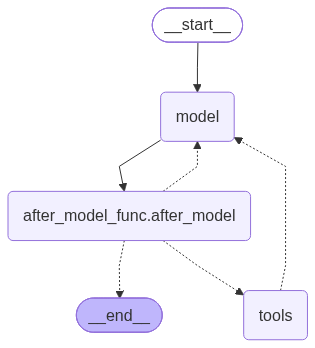

In [172]:
display(Image(agent.get_graph().draw_mermaid_png()))

In [178]:
exploaration_messages = agent.invoke(input={"messages": [HumanMessage("Can you give me information about the employees? all the information that you cant find.")]})

[values] {'messages': [HumanMessage(content='Can you give me information about the employees? all the information that you cant find.', additional_kwargs={}, response_metadata={}, id='fe957e99-c9c1-4295-9933-d9993ebe7d6a')]}
[updates] {'model': {'messages': [AIMessage(content=[{'id': 'rs_0348f88ed0ea0075006a8dd854bfe087d0b78772919d4cb798', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqjdhcBidwd0iXciIuGa5UVwdoH_fjW5moHt4yWGjlQCQ7nYKpkM1OCpqfUxvdzrrfghSMl25gQw1I2bLDS23GiBj5EO1u7SvwfW-pZ1LPyZds6L6qC33yl8V6-JZ3Q_jfebTFapEzewbAoL-N4cUUDS-UpNYdhqGzGBpIiYzyVdclOgRlM0WrRdScunExcOQw-ZnJQZwBi2ncfwycE45IdodGHDtMdoG8iVpXq02ViRCtnIqCIaq5Mf2CTT3xuOHf9F9hK0s7dwIksQ5aBGfCd9UyWIKzq6Q2HoqJ-eZ27-xccxzCEeWIkhKEDNfxfZGEp0Vp8POCbYn8Adq55koX5_75e12IC2mQGLG9eWCd0N87J7U5xbawbjlFF-mE1jqcds0zhKAksASdznYXjU2itz7g4Gs21ToSA_G22FaNopFwFCWy7lc7aWBYGB9yXNf9haCroAXA-bgbTysHGcY3Z9GvvKRL50BCMvb2zyo1uD71PNLEey61DchGRupH3QjTXFw3wz6nR90oyA5kp9zdOWrOsKg6lDeUnPHd8xGaVLUnEzVekK5lVbq6pgbufEJHR

In [165]:
print_conversation(exploaration_messages['messages'])

================================ Human Message =================================

Can you give me information about the employees? all the information that you cant find.
================================== Ai Message ==================================

[{'id': 'rs_04faad13d1f6b48a006a8dd614637887d1bb54e8b7a78a808e', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqjdYbIRkDNNEliX3J9anhd6AG33W7BydAX8q0_osOSWIu2JHh5t-TTrYWtwDg49V-LwfPT9F81Hh96U23hFIWu_QcgZCPreLHNz3s-leHen0swwTWUkEhBk1mewJ7znNqWoNHwT9YHT6lT9L1nBbeTTAw1EiUW2kp8WXixyx4hQOvloqou0GXuBdEbJBM08gv080q72rZxhTolrSaUQO8oC2OKHj4f1URkyEzzOXCjVuy7JdxdCDHSS1Q8bpc653iEnDLD--xwMU7nTL2Ey2rhRTAEHyVXQdr8VndJJFx0grHib9l3LoMIm11VloHFsgQNcn-QSpeH6akATV4EvSHDsfRfEkVC0jsn9xLunc96ct7Vz4SDtOPmFJjIoZ8mqrNORCRcORoHdayLk-UMj2g52eyyYcw1BUqDBNQHg_u3GXYsbvNZWI1jguoZC49HTZ5lLx5XEpl6TERYwCs-zxixo1R5DBeuKoPs-1Hv0pmUFp6_mDGHpnvedhmbVP0Nce-pgwNhVpjz6qzW4PABsoVoVMOsVndQN2fXDyv5-TYuCHlJJRrMAD0x6GV7vn18_dhcJo3X_Dik6X3OcNChonaJxmB8

In [ ]:
# RAG - Retrieval Augmented Genration
# CAG - Cache Augmented Gneration

In [ ]:
# CODE SNIPPETS

In [5]:
from google.colab import userdata
from langchain.messages import AIMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from pydantic import SecretStr

def print_response(response: AIMessage):
  print(f"Response id: {response.id}")
  if response.usage_metadata is not None:
    input_tokens = response.usage_metadata.get("input_tokens", 0)
    cached_tokens = response.usage_metadata.get("input_token_details", {}).get("cache_read", 0)
    output_tokens = response.usage_metadata.get("output_tokens", 0)
    reasoning_tokens = response.usage_metadata.get("input_token_details", {}).get("reasoning", 0)

    print(f"Input tokens: {input_tokens}")
    print(f"Cached tokens: {cached_tokens}")
    print(f"Output tokens: {output_tokens}")
    print(f"Reasoning tokens: {reasoning_tokens}")




In [8]:
api_key = SecretStr(userdata.get('OPENAI_KEY'))

openai_model = ChatOpenAI(
    model_name="gpt-5-nano",
    openai_api_key=api_key,
    reasoning_effort="low")

messages = [
    SystemMessage("You are a history teacher. And you have to answer questions."),
    HumanMessage("Write me the 20 most impoetant dates in the history of Ancient Rome.")
]

response = openai_model.invoke(input=messages)

print_response(response=response)


Response id: lc_run--01a0290d-7fcd-78f2-955a-170f078aa8c1-0
Input tokens: 41
Cached tokens: 0
Output tokens: 2104
Reasoning tokens: 0


In [9]:
first_response = openai_model.invoke(input=[HumanMessage("Hi, Im Ivan from Bulgaria. How are you today?")])


In [15]:
second_response = openai_model.invoke(input=[
    HumanMessage("Hi, Im Ivan from Bulgaria. How are you today?"),
    first_response,
    HumanMessage("What do you remember about me?")
    ])
print(second_response)


content='I don’t have memory of past chats unless you share details in this conversation. So right now I only know: you’re Ivan from Bulgaria and you asked how I’m doing.\n\nIf you’d like, you can tell me some preferences or topics you want me to remember for this session, and I’ll tailor my replies accordingly. What would you like to talk about or do next?' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 150, 'prompt_tokens': 85, 'total_tokens': 235, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EFddYIwEoQqsl2MYaxHdilCKYY79m', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--01a0291a-69a9-7fe1-8ea4-31c813c6aebf-0' 

In [46]:
from google.colab import userdata
from langchain.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain.tools import tool
from pydantic import SecretStr
from typing import List

def print_conversation(conversation: List[AIMessage]):
  """
  Getting the conversation and printing it of the database status.
  """
  for message in conversation:
    message.pretty_print()


In [48]:
@tool
def get_database_status() -> str:
  """
  Getting the status of the database.
  """
  return "Its Ok!"

In [49]:
api_key = SecretStr(userdata.get('OPENAI_KEY'))

openai_model = ChatOpenAI(model_name="gpt-5-nano", api_key=api_key).bind_tools([get_database_status])


In [50]:
first_response = openai_model.invoke(input=[
    HumanMessage("What is the current status of the database??"),
])



In [51]:
print_conversation([first_response])

================================== Ai Message ==================================
Tool Calls:
  get_database_status (call_kiesrrEq6GbyahUFsyvOtZay)
 Call ID: call_kiesrrEq6GbyahUFsyvOtZay
  Args:


In [52]:
status = get_database_status.invoke("")
print(status)

Its Ok!


In [54]:
tool_call_answer = ToolMessage(status, tool_call_id=first_response.tool_calls[0]["id"])